In [8]:
import pandas as pd
df = pd.read_csv("../data/processed/data_with_flags.csv")
print(df.shape)
df.head()

(5184, 18)


,ecc,N,gammaG,Esoil,Econc,Dbot,H1,H2,H3,Mr_t,Mt_t,Mr_c,Mt_c,outlier_global,outlier_group,outlier_mad,suspect_row,M_ov
0,0,2000,0.9,25,30000,17,0.8,1.0,0.8,0.082100,0.055648,0.082100,0.055648,False,False,False,False,0
1,10,2000,0.9,25,30000,17,0.8,1.0,0.8,-0.597084,-0.233470,1.160648,0.605016,False,False,False,False,20000
2,18,2000,0.9,25,30000,17,0.8,1.0,0.8,-1.094196,-0.566130,1.908188,0.947770,False,False,False,False,36000
3,26,2000,0.9,25,30000,17,0.8,1.0,0.8,-1.416485,-0.865039,2.844706,1.310545,False,False,False,False,52000
4,0,2000,0.9,25,37000,17,0.8,1.0,0.8,0.079570,0.054213,0.079570,0.054213,False,False,False,False,0


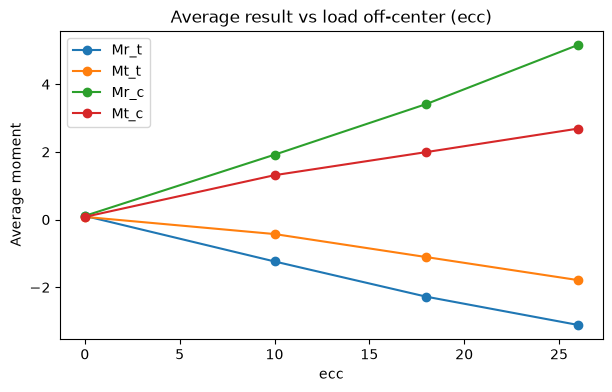

In [9]:
import matplotlib.pyplot as plt

outputs = ["Mr_t", "Mt_t", "Mr_c", "Mt_c"]

df.groupby("ecc")[outputs].mean().plot(marker="o", figsize=(7, 4))
plt.title("Average result vs load off-center (ecc)")
plt.xlabel("ecc")
plt.ylabel("Average moment")
plt.savefig("../figures/C_ecc_effect.png", dpi=150, bbox_inches="tight")
plt.show()

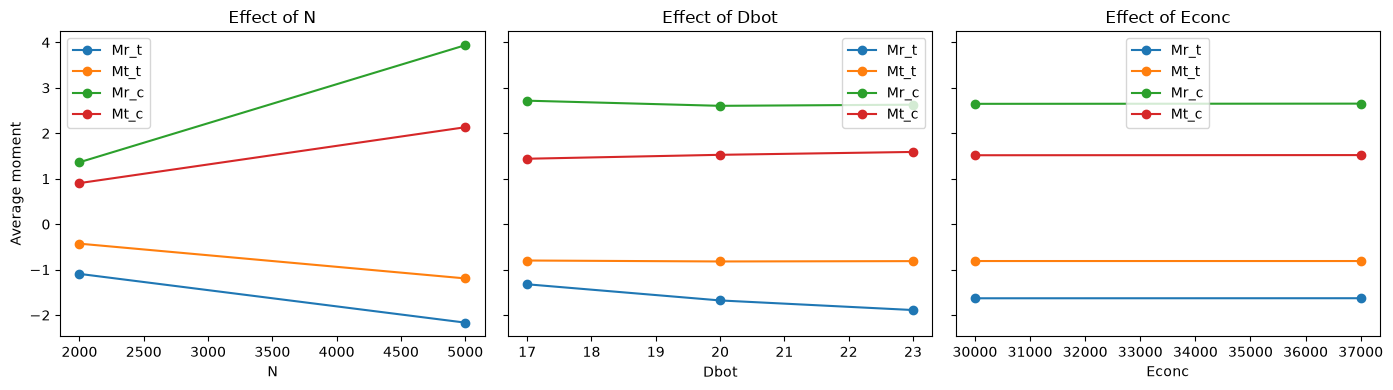

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, col in zip(axes, ["N", "Dbot", "Econc"]):
    df.groupby(col)[outputs].mean().plot(marker="o", ax=ax)
    ax.set_title(f"Effect of {col}")
    ax.set_xlabel(col)

axes[0].set_ylabel("Average moment")
plt.tight_layout()
plt.savefig("../figures/C_other_inputs.png", dpi=150, bbox_inches="tight")
plt.show()

['outlier_global', 'outlier_group', 'outlier_mad', 'suspect_row']


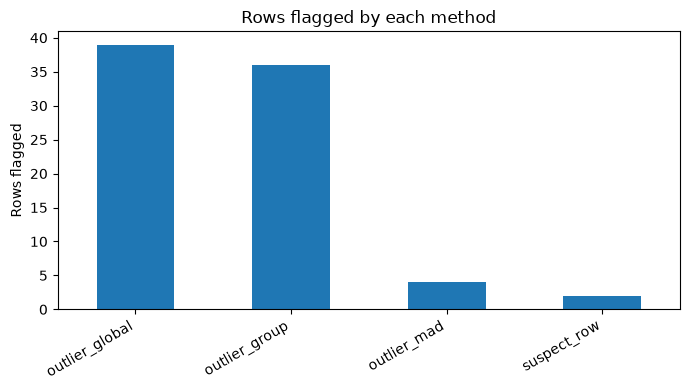

In [11]:
flag_cols = [c for c in df.columns if c.startswith("outlier") or c == "suspect_row"]
print(flag_cols)

df[flag_cols].astype(int).sum().plot(kind="bar", figsize=(7, 4))
plt.title("Rows flagged by each method")
plt.ylabel("Rows flagged")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../figures/C_flag_counts.png", dpi=150, bbox_inches="tight")
plt.show()

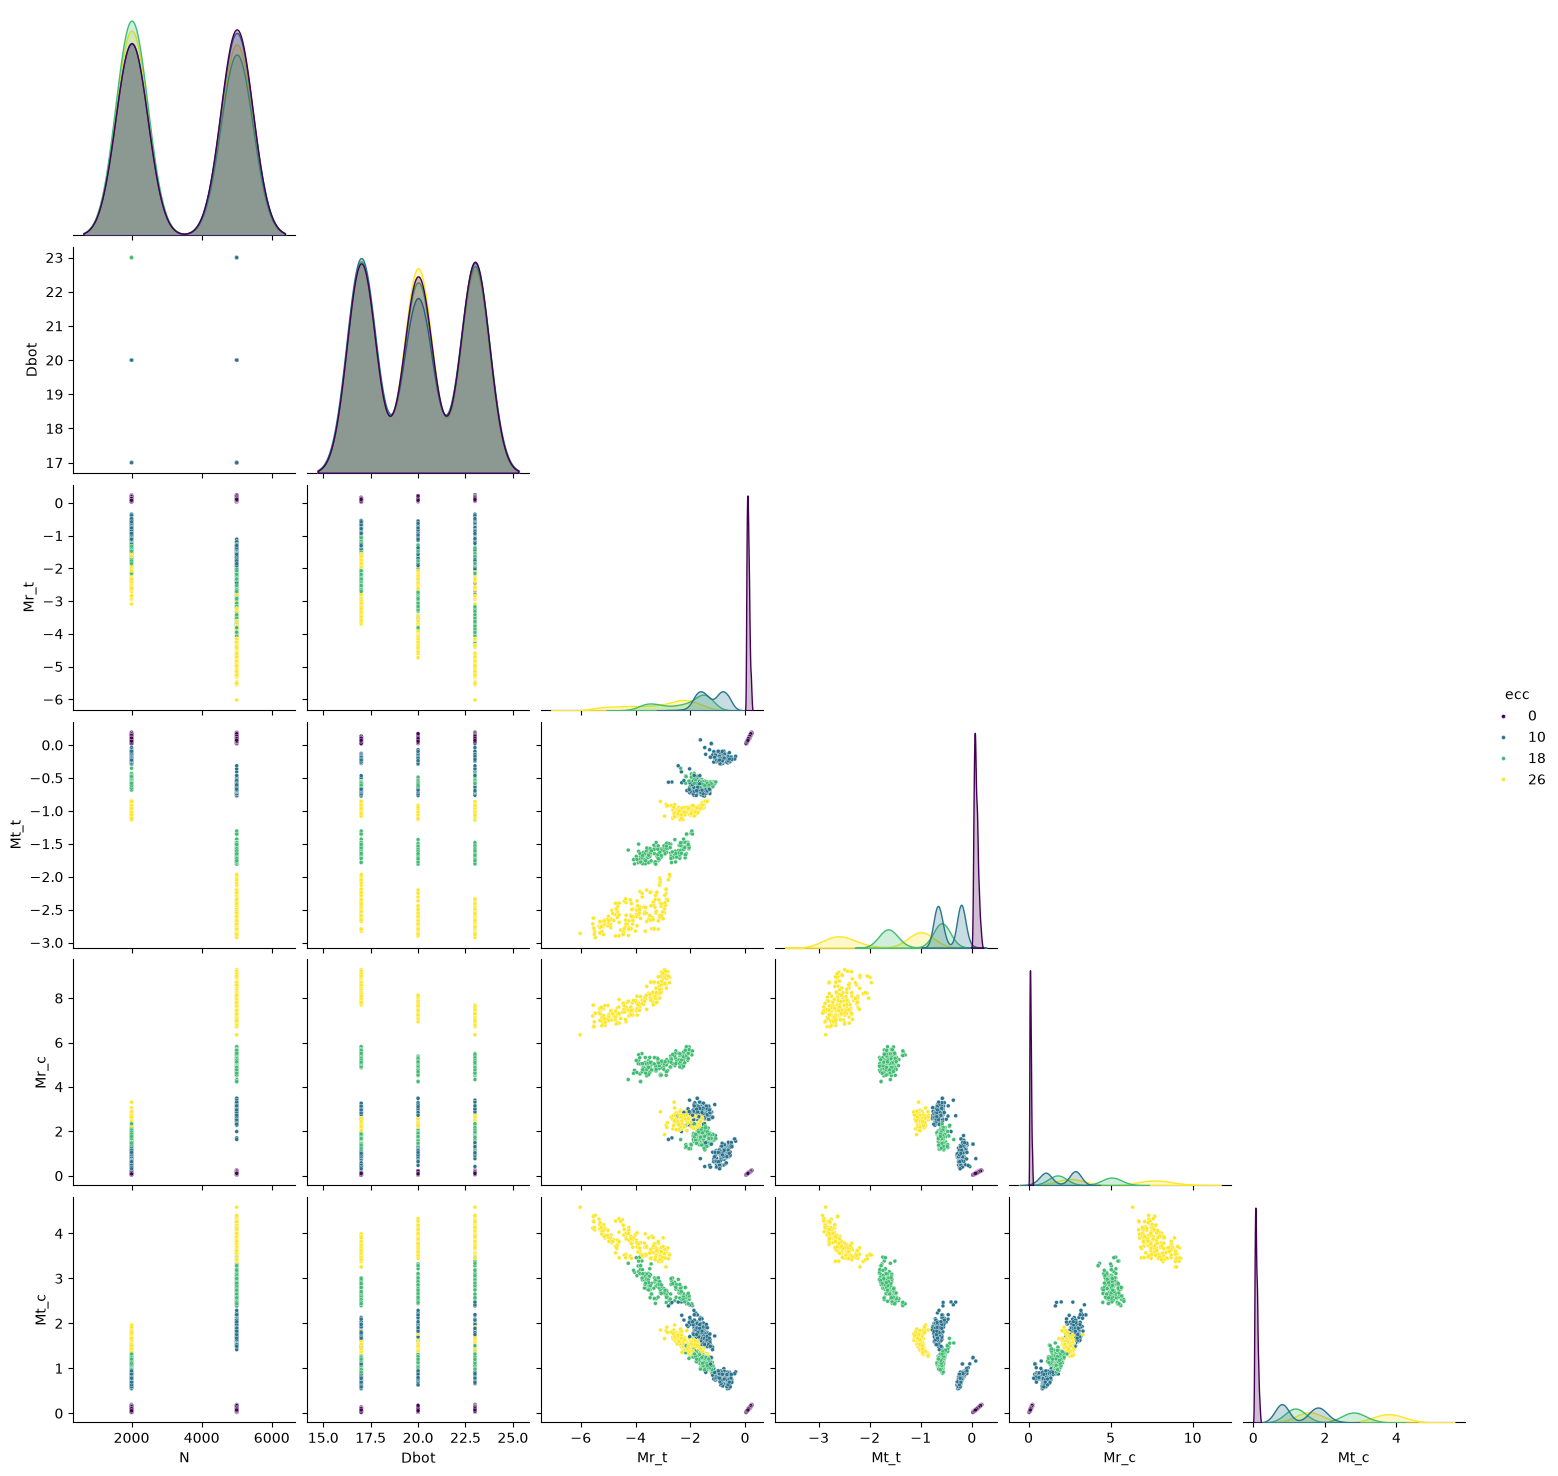

In [12]:
import seaborn as sns

subset = ["ecc", "N", "Dbot", "Mr_t", "Mt_t", "Mr_c", "Mt_c"]
sns.pairplot(df.sample(1500, random_state=42)[subset],
             hue="ecc", palette="viridis", corner=True, plot_kws={"s": 8})
plt.savefig("../figures/C_pairplot.png", dpi=120, bbox_inches="tight")
plt.show()

Share of variation explained: [0.96728065 0.02405378]


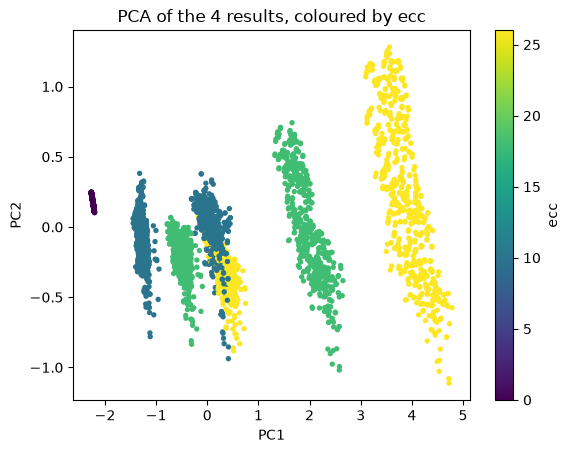

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(df[["Mr_t", "Mt_t", "Mr_c", "Mt_c"]])
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)
print("Share of variation explained:", pca.explained_variance_ratio_)

plt.scatter(pcs[:, 0], pcs[:, 1], c=df["ecc"], cmap="viridis", s=8)
plt.colorbar(label="ecc")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of the 4 results, coloured by ecc")
plt.savefig("../figures/C_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
flag_cols = [c for c in df.columns if c.startswith("outlier") or c == "suspect_row"]

outliers = df[df[flag_cols].astype(bool).any(axis=1)].copy()
outliers.insert(0, "row_id", outliers.index)
outliers["flagged_by"] = outliers[flag_cols].astype(bool).apply(
    lambda r: ", ".join(r.index[r]), axis=1)

print("Outlier rows:", len(outliers))
outliers.to_csv("../data/processed/outliers_only.csv", index=False)
outliers.head()

Outlier rows: 77


,row_id,ecc,N,gammaG,Esoil,Econc,Dbot,H1,H2,H3,Mr_t,Mt_t,Mr_c,Mt_c,outlier_global,outlier_group,outlier_mad,suspect_row,M_ov,flagged_by
43,43,26,5000,0.9,75,30000,17,0.8,1.0,0.8,-2.903879,-2.189199,8.934685,3.258198,True,False,False,False,130000,outlier_global
47,47,26,5000,0.9,75,37000,17,0.8,1.0,0.8,-2.882777,-2.189082,9.021212,3.255682,True,False,False,False,130000,outlier_global
107,107,26,5000,0.9,75,30000,17,0.8,1.0,1.2,-2.821271,-2.052222,8.931811,3.409601,True,False,False,False,130000,outlier_global
111,111,26,5000,0.9,75,37000,17,0.8,1.0,1.2,-2.799806,-2.047175,8.995092,3.435975,True,False,False,False,130000,outlier_global
175,175,26,5000,0.9,75,37000,17,0.8,1.0,1.6,-2.755418,-1.994403,8.940153,3.542370,True,False,False,False,130000,outlier_global


In [15]:
print((df["M_ov"] == df["N"] * df["ecc"]).all())

True


In [16]:
clean = df[~df["suspect_row"].astype(bool)]
print("Rows before:", len(df), "| after:", len(clean))

before = df.groupby("ecc")[outputs].mean()
after = clean.groupby("ecc")[outputs].mean()
print("Biggest change in any average:")
print((before - after).abs().max())

Rows before: 5184 | after: 5182
Biggest change in any average:
Mr_t    0.000686
Mt_t    0.000325
Mr_c    0.002821
Mt_c    0.000706
dtype: float64
